# AMN Models - QP


In [1]:
from Library.Build_Model_lite_grads import *


DIRECTORY = '../../'
font = 'arial'
# We declare this function here and not in the
# function-storing python file to modify it easily
# as it can change the printouts of the methods
def printout(filename, Stats, model, time): 
    # printing Stats
    print('Stats for %s CPU-time %.4f' % (filename, time))
    print('R2 = %.4f (+/- %.4f) Constraint = %.4f (+/- %.4f)' % \
          (Stats.train_objective[0], Stats.train_objective[1],
           Stats.train_loss[0], Stats.train_loss[1]))
    print('Q2 = %.4f (+/- %.4f) Constraint = %.4f (+/- %.4f)' % \
          (Stats.test_objective[0], Stats.test_objective[1],
           Stats.test_loss[0], Stats.test_loss[1]))

In [124]:
import shutil
import numpy as np

# Create, train and evaluate AMN_QP o models with FBA simulated training set for E. coli core
# with EB or UB with a mechanistic layer

# What you can change 
seed = 10
ratio_test = 0.2 # part of the training set removed for test
np.random.seed(seed=seed)  

strain = "SLAB"
trainname = f'{strain}_UB_1' # the training set file name
# size = int(trainname.split('_')[-1]) # number of runs must be lower than the number of element in trainname
# End of What you can change

# Create model and run GD for X and Y randomly drawn from trainingfile
trainingfile = DIRECTORY+'Dataset_model/'+trainname

# Copy the model without size
# remove the size part if present
new_train_name = "_".join(trainname.split('_')[:-1])

trainingfile = './Dataset_model/'+new_train_name
# copy the model and paste with new name
shutil.copyfile(DIRECTORY+'Dataset_model/'+trainname + ".npz", trainingfile + ".npz")
shutil.copyfile(DIRECTORY+'Dataset_model/'+trainname + ".xml", trainingfile + ".xml")

print(f"Training and Testing file used: {trainingfile}")

biomass_reaction_name = 'BIOMASS_Ec_iML1515_core_75p37M'
# Get the target index for biomass reaction
train_parameter = TrainingSet()
train_parameter.load(trainingfile)
target_index = [r.id for r in train_parameter.model.reactions].index(biomass_reaction_name)
# size = original_parameter.Y.shape[0]

# End of What you can change
  


model = Neural_Model(trainingfile = trainingfile, 
                     objective=[biomass_reaction_name],  
                     model_type='AMN_QP', 
                     timestep = 4, #4, # The number of time the iterative  schema is rolled out
                     learn_rate=0.9, #0.9,
                     train_rate= 0.001, # 0.1,
                     scaler=True,
                     n_hidden = 1, 
                     hidden_dim = 2000,
                     epochs= 4000,# 800, 
                     xfold=1,
                     verbose=True)
ID = np.random.choice(model.X.shape[0], 
                      size=int(model.X.shape[0]*ratio_test), replace=False)
Xtest,  Ytest  = model.X[ID,:], model.Y[ID,:]
Xtrain, Ytrain = np.delete(model.X, ID, axis=0), np.delete(model.Y, ID, axis=0)

model.printout()

# Train and evaluate
reservoirname = trainname+'_'+model.model_type
reservoirfile = DIRECTORY+'Reservoir/'+reservoirname
start_time = time.time()
model.X, model.Y = Xtrain, Ytrain
reservoir, pred, stats, history = train_evaluate_model(model, verbose=2)
delta_time = time.time() - start_time


# Printing cross-validation results
printout(reservoirname, stats, model, delta_time)

# Save, reload and run idependent test set
# reservoir.save(reservoirfile)
# reservoir.load(reservoirfile)
# reservoir.printout()
start_time = time.time()
reservoir.X, reservoir.Y = Xtest, Ytest
X, Y = model_input(reservoir, verbose=False)
pred, stats = evaluate_model(reservoir.model, X, Y, reservoir, verbose=False)
delta_time = time.time() - start_time
delta_time = time.time() - start_time
printout('Test set', stats, model, delta_time)



Training and Testing file used: ./Dataset_model/SLAB_UB
Loading model from: c:\Users\rh2310\projects\amn_release\Lab_Notebooks\AMN\..\..\Dataset_model\SLAB_UB_1.xml: True
Loading model from: c:\Users\rh2310\projects\amn_release\Lab_Notebooks\AMN\..\..\Dataset_model\SLAB_UB_1.xml: True
number of reactions:  3682 3682
number of metabolites:  1877
filtered measurements size:  1
training file: ./Dataset_model/SLAB_UB
model type: AMN_QP
model scaler: 1.0
model input dim: 46
model output dim: 1
model medium bound: UB
timestep: 4
training set size (99, 46) (99, 1)
nbr hidden layer: 1
hidden layer size: 2000
activation function: relu
gradient learn rate: 0.9
gradient decay rate: 0.9
training epochs: 4000
training regression: True
training learn rate: 0.001
training dropout: 0.25
training batch size: 5
training validation iter: 0
training xfold: 1
training early stopping: False
AMN scaler 24000.0
QP input shape (80, 46) (80, 4)
----------------------------------- AMN_QP
Dense layer n_hidden, hi

In [125]:
# Access NN gradient history
if hasattr(history, 'gradient_history'):
    nn_gradients = history.gradient_history
    # List of dicts: [{'epoch': 0, 'grad_0_kernel:0': 0.123, ...}, ...]

# Access NN weight history
if hasattr(history, 'weight_history'):
    nn_weights = history.weight_history
    # List of dicts: [{'epoch': 0, 'layer_0_dense_kernel': 1.234, ...}, ...]

In [126]:
Vf, mm_stats, mech_grads = MM_QP(model, history=True, get_stats=True)

Figure saved to nn_analysis_SLAB_4000_epoch.png
Figure saved to mech_analysis_SLAB_4000_epoch.png
Figure saved to full_analysis_SLAB_4000_epoch.png


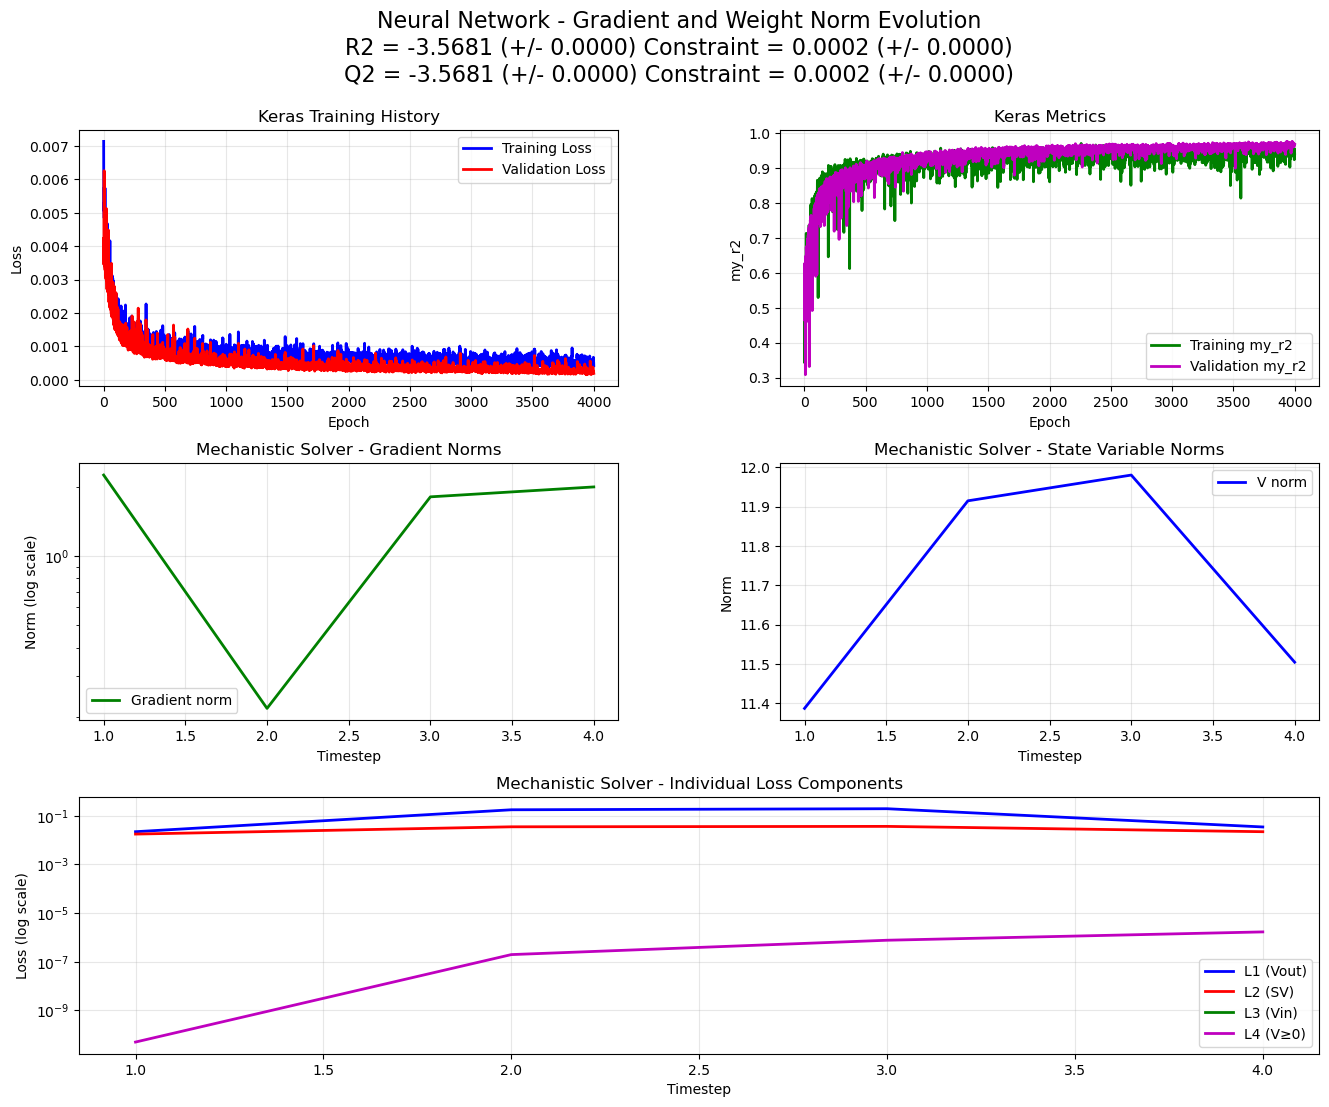

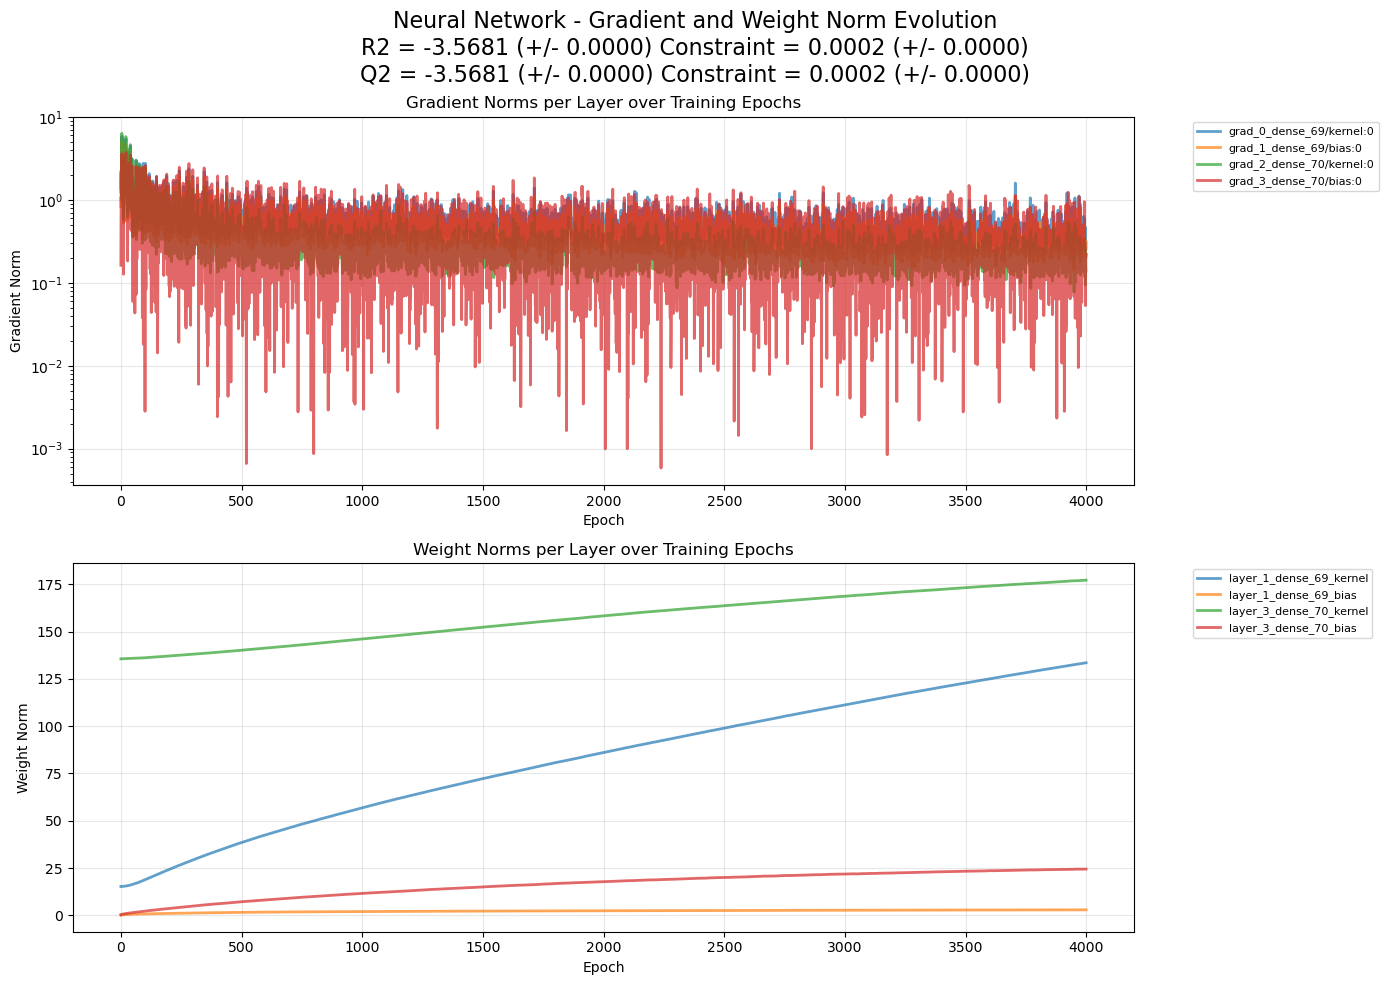

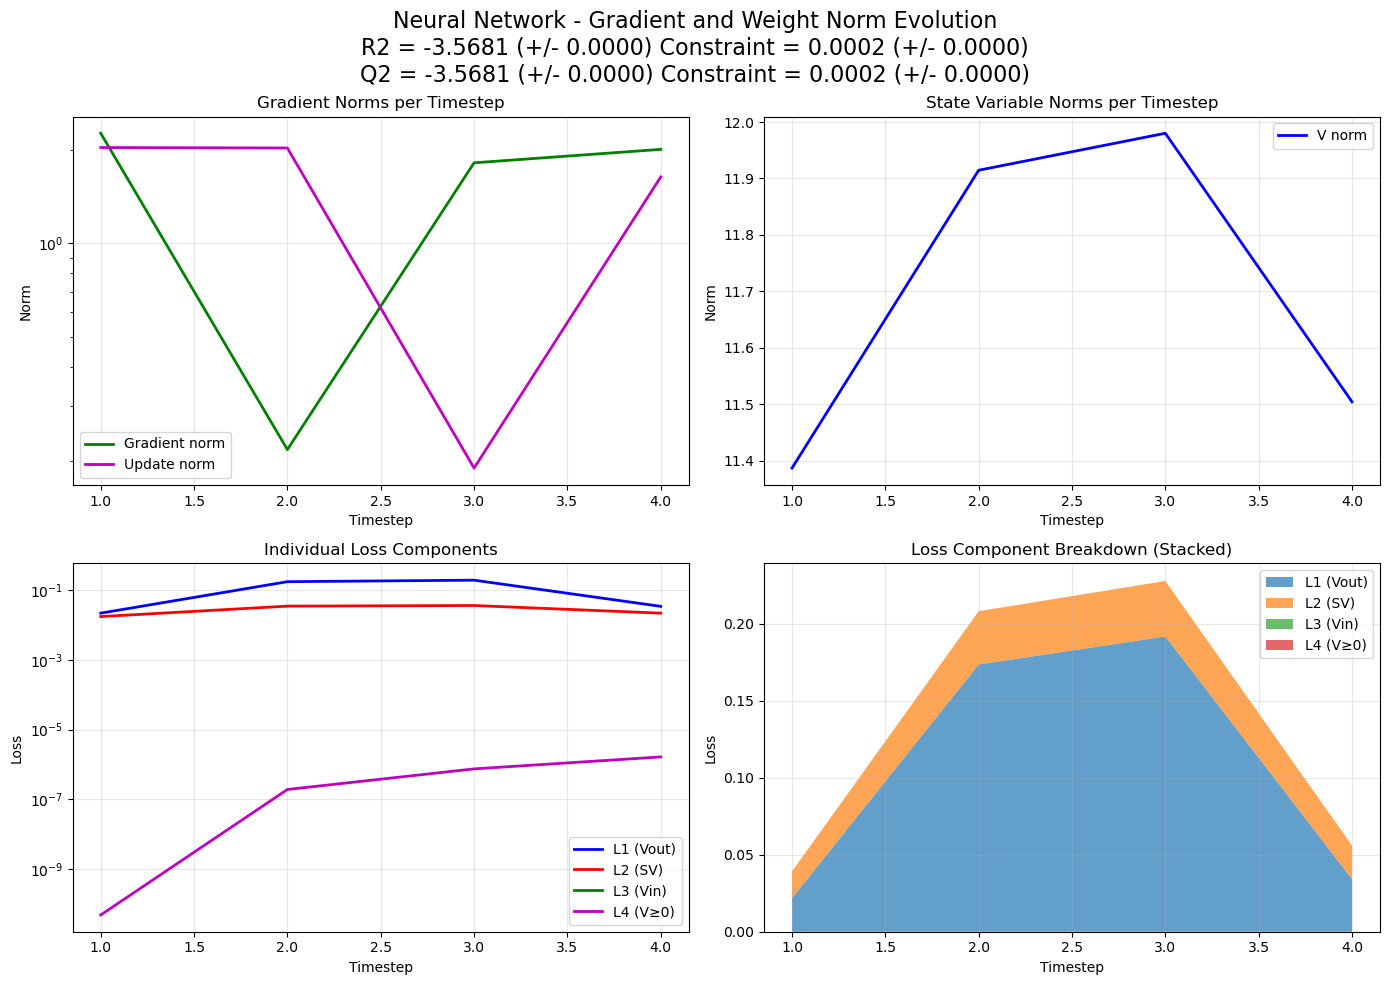

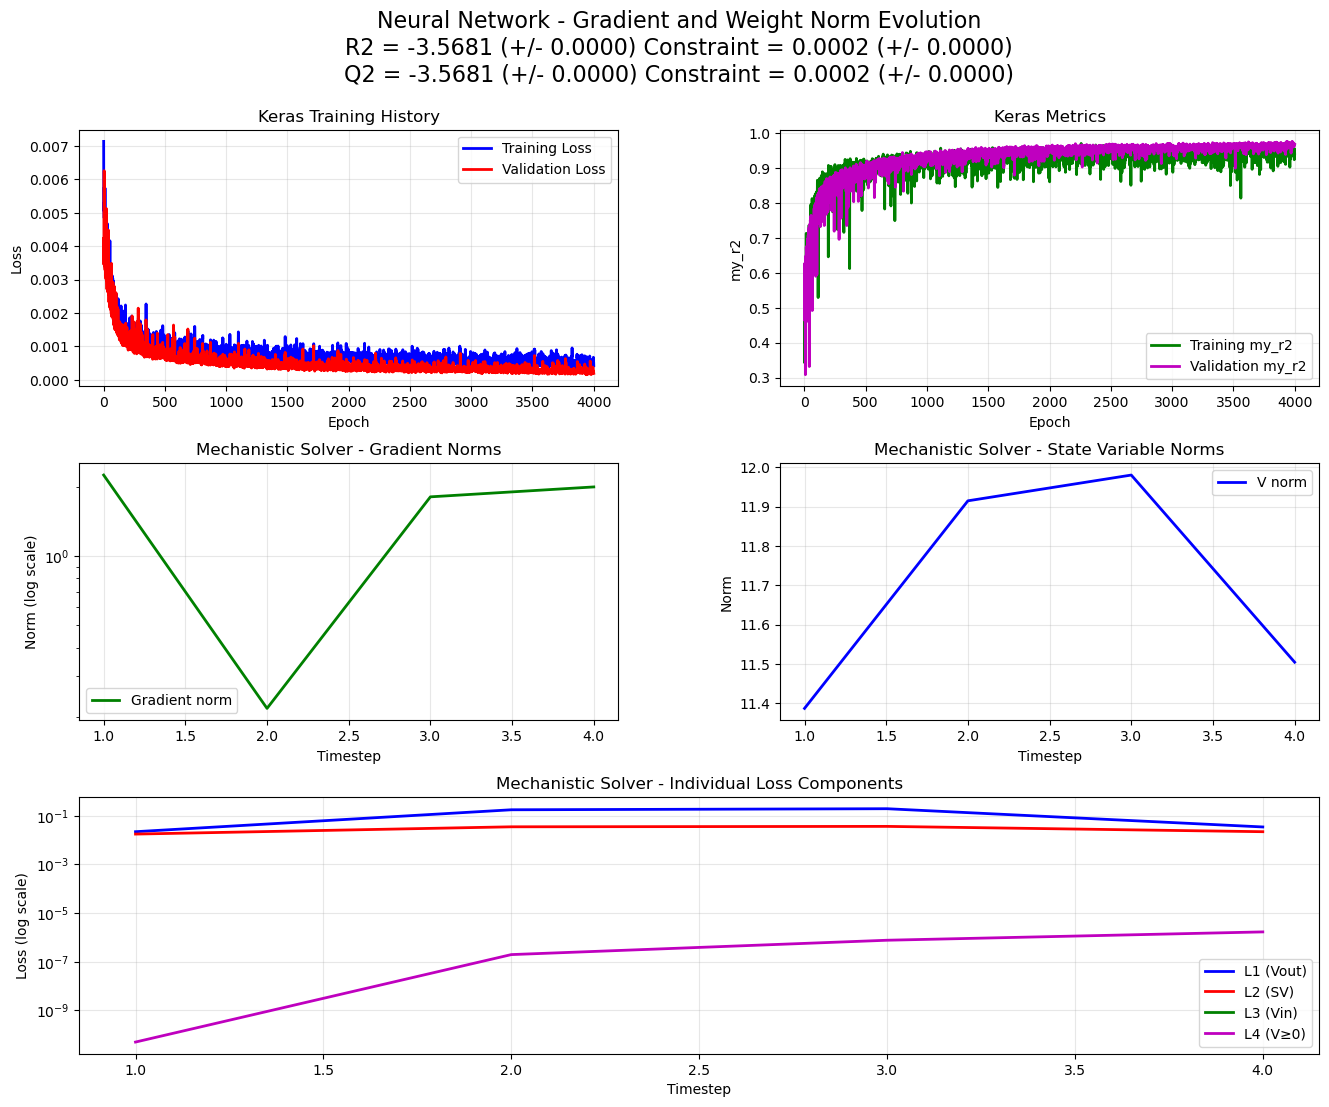

In [171]:
plot_nn_gradients(history.gradient_history, history.weight_history, 
                  save_path='nn_analysis_SLAB_4000_epoch.png', Stats=stats)
plot_mechanistic_gradients(mech_grads, 'QP', save_path='mech_analysis_SLAB_4000_epoch.png', Stats=stats)
plot_combined_history(history, mech_grads, 'QP', save_path='full_analysis_SLAB_4000_epoch.png', Stats=stats)

In [129]:
def check_vanishing_gradients(gradient_history, threshold=1e-7):
    """Check if any layer has vanishing gradients"""
    for epoch_data in gradient_history:
        for key, value in epoch_data.items():
            if key != 'epoch' and value < threshold:
                print(f"Epoch {epoch_data['epoch']}: {key} = {value:.2e}")
                return True
    return False
def check_exploding_gradients(gradient_history, threshold=100):
    """Check if any layer has exploding gradients"""
    for epoch_data in gradient_history:
        for key, value in epoch_data.items():
            if key != 'epoch' and value > threshold:
                print(f"Epoch {epoch_data['epoch']}: {key} = {value:.2e}")
                return True
    return False

def analyze_constraint_satisfaction(mech_grad_history):
    """Analyze how well constraints are satisfied over time"""
    import pandas as pd
    
    df = pd.DataFrame({
        'timestep': mech_grad_history['timestep'],
        'L1_Vout': mech_grad_history['L1_loss'],
        'L2_SV': mech_grad_history['L2_loss'],
        'L3_Vin': mech_grad_history['L3_loss'],
        'L4_Vpos': mech_grad_history['L4_loss']
    })
    
    print("Constraint Satisfaction Summary:")
    print(df.describe())
    
    # Check convergence
    final_losses = df.iloc[-10:].mean()
    print("\nFinal 10-step average losses:")
    print(final_losses)
    
    return df

In [130]:
if check_vanishing_gradients(history.gradient_history):
    print("Vanishing gradients detected!")
    print("Consider:")
    print("  - Adjusting learning rate")
    print("  - Changing activation functions")
    print("  - Adding batch normalization")
if check_exploding_gradients(history.gradient_history):
    print("Exploding gradients detected!")
    print("Consider:")
    print("  - Gradient clipping")
    print("  - Lower learning rate")
    print("  - Weight regularization")
df = analyze_constraint_satisfaction(mech_grads)
df        

Constraint Satisfaction Summary:
       timestep   L1_Vout     L2_SV  L3_Vin       L4_Vpos
count  4.000000  4.000000  4.000000     4.0  4.000000e+00
mean   2.500000  0.105321  0.027464     0.0  6.509096e-07
std    1.290994  0.089776  0.009286     0.0  7.430632e-07
min    1.000000  0.021782  0.017395     0.0  4.911996e-11
25%    1.750000  0.031053  0.020687     0.0  1.450474e-07
50%    2.500000  0.103855  0.028205     0.0  4.730753e-07
75%    3.250000  0.178123  0.034982     0.0  9.789374e-07
max    4.000000  0.191791  0.036051     0.0  1.657439e-06

Final 10-step average losses:
timestep    2.500000e+00
L1_Vout     1.053209e-01
L2_SV       2.746405e-02
L3_Vin      0.000000e+00
L4_Vpos     6.509096e-07
dtype: float64


,timestep,L1_Vout,L2_SV,L3_Vin,L4_Vpos
0,1,0.021782,0.017395,0.0,4.911996e-11
1,2,0.173567,0.034626,0.0,1.933802e-07
2,3,0.191791,0.036051,0.0,7.527703e-07
3,4,0.034144,0.021785,0.0,1.657439e-06


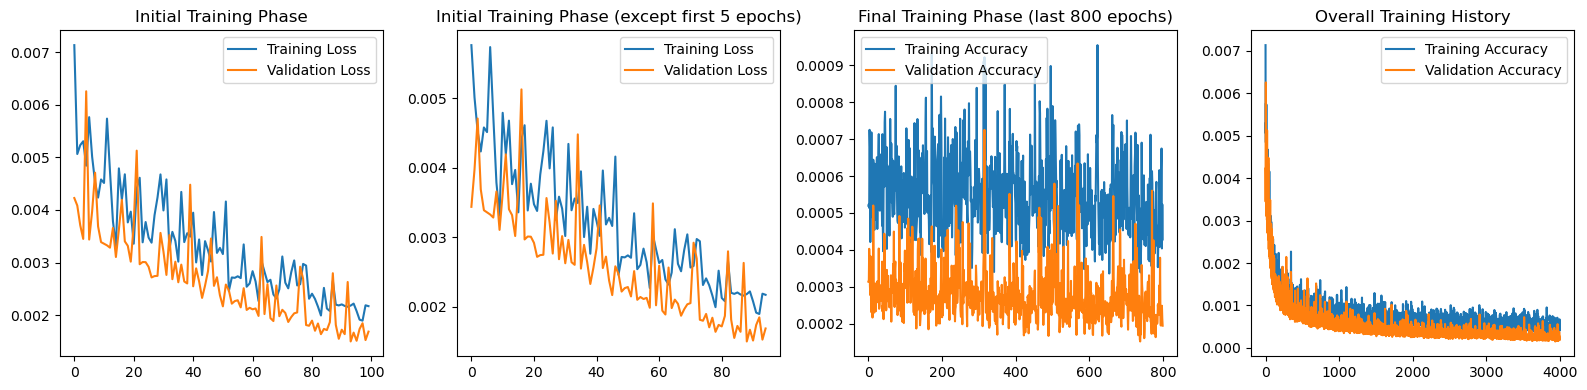

In [155]:
import matplotlib.pyplot as plt
init_L = 100
plot_scale = -8
fig = plt.figure(figsize=(16, 4))
ax1, ax2, ax3, ax4 = fig.subplots(1, 4)
ax1.plot(history.history['loss'][:init_L], label='Training Loss')
ax1.plot(history.history['val_loss'][:init_L], label='Validation Loss')
ax1.set_title('Initial Training Phase')
ax1.legend()
ax2.plot(history.history['loss'][5:init_L], label='Training Loss')
ax2.plot(history.history['val_loss'][5:init_L], label='Validation Loss')
ax2.set_title('Initial Training Phase (except first 5 epochs)')
ax2.legend()
ax3.plot(history.history['loss'][plot_scale*init_L:], label='Training Accuracy')
ax3.plot(history.history['val_loss'][plot_scale*init_L:], label='Validation Accuracy')
ax3.set_title(f'Final Training Phase (last {abs(plot_scale)*init_L} epochs)')
ax3.legend()
ax4.plot(history.history['loss'], label='Training Accuracy')
ax4.plot(history.history['val_loss'], label='Validation Accuracy')
ax4.legend()
ax4.set_title('Overall Training History')
plt.tight_layout(); plt.show()

In [133]:
# To make the Ytest shape acceptable for evaluation, we augment it
# by adding zero constraints as vertical columns
# augmented_ytest = np.hstack( [Y, np.zeros((Ytest.shape[0], NBR_CONSTRAINT))] )
# y_pred, stats = evaluate_model(reservoir.model, test_parameter.X, test_parameter.Y, model, False, verbose=True)
# Get the inpuyt and output shapes for later slicing
param = copy.copy(model)
X, Y = model_input(param, verbose=True)
# yp is the model prediction of phenotype (growth rates)
end = Y.shape[1] - NBR_CONSTRAINT

AMN scaler 24000.0
QP input shape (80, 46) (80, 4)


---------- 1


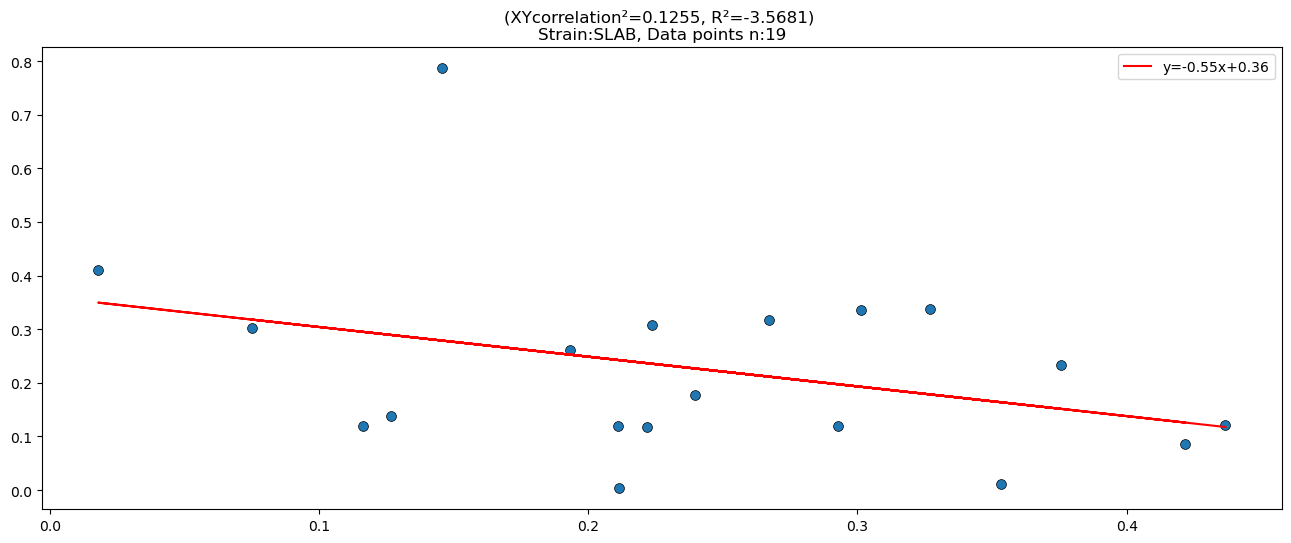

In [169]:
reservoir.X, reservoir.Y = Xtest, Ytest
# reservoir.b_ext, reservoir.b_int =  btest, bint
X, Y = model_input(reservoir,verbose=False)
pred, stats = evaluate_model(reservoir.model, X, Y, reservoir, verbose=False)
yp =  pred[:,:end]

y = np.array(yp.flatten())
x = np.array(Ytest).flatten()
m, b = np.polyfit(x, y, 1)
fig = plt.figure(figsize=(16,6))
ax1 = fig.subplots(1,1)
ax1.plot(x, m*x + b, color='red', label=f'y={m:.2f}x+{b:.2f}')
# find R2
correlation_matrix = np.corrcoef(x, y)
correlation_xy = correlation_matrix[0,1]
r_squared = correlation_xy**2

r_2 = r2_score(x, y)


subtitle= (f"Strain:{strain}, Data points n:{y.shape[0]}")
ax1.set_title(f"(XYcorrelation²={r_squared:.4f}, R²={r_2:.4f}) \n"
              f"{subtitle}"
              )
ax1.scatter(x, y,s=50,edgecolors='black', linewidths=0.5)
plt.legend()

---------- 1


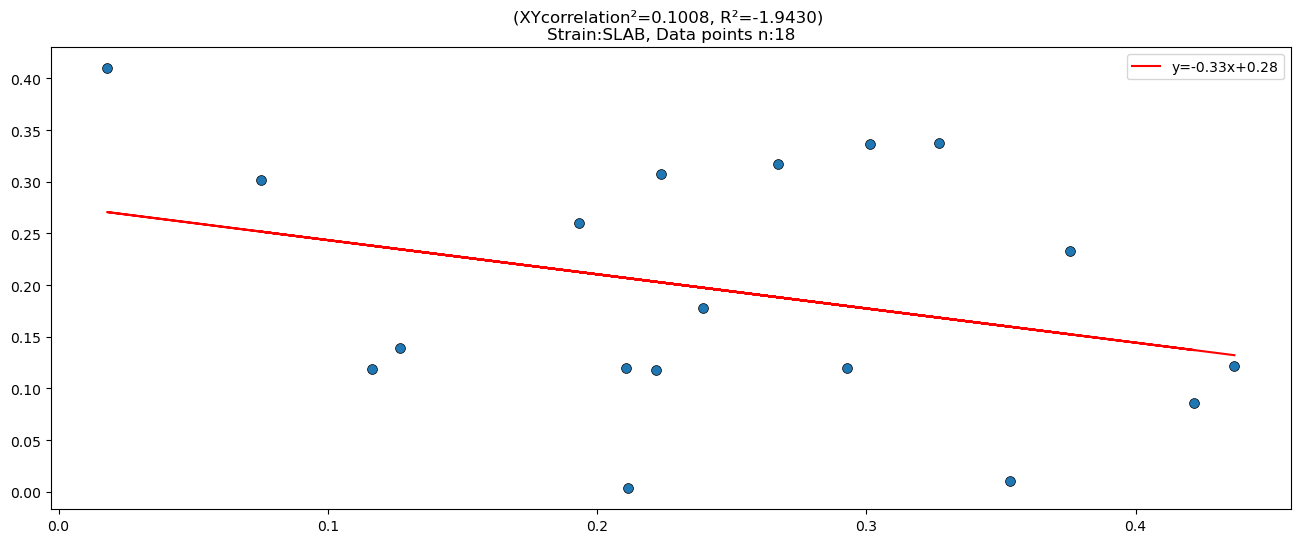

In [170]:
reservoir.X, reservoir.Y = Xtest, Ytest
# reservoir.b_ext, reservoir.b_int =  btest, bint
X, Y = model_input(reservoir,verbose=False)


pred, stats = evaluate_model(reservoir.model, X, Y, reservoir, verbose=False)
yp =  pred[:,:end]

percentile_lower = 25
percentile_upper = 75
q1 = np.percentile(yp, percentile_lower)
q3 = np.percentile(yp, percentile_upper)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
filtered_preds = [True if lower_bound <= pred <= upper_bound else False for pred in yp]
yp = yp[filtered_preds]



y = np.array(yp.flatten())
x = np.array(Ytest[filtered_preds]).flatten()
m, b = np.polyfit(x, y, 1)
fig = plt.figure(figsize=(16,6))
ax1 = fig.subplots(1,1)
ax1.plot(x, m*x + b, color='red', label=f'y={m:.2f}x+{b:.2f}')
# find R2
correlation_matrix = np.corrcoef(x, y)
correlation_xy = correlation_matrix[0,1]
r_squared = correlation_xy**2

r_2 = r2_score(x, y)


subtitle= (f"Strain:{strain}, Data points n:{y.shape[0]}")
ax1.set_title(f"(XYcorrelation²={r_squared:.4f}, R²={r_2:.4f}) \n"
              f"{subtitle}"
              )
ax1.scatter(x, y,s=50,edgecolors='black', linewidths=0.5)
plt.legend() 


---------- 1


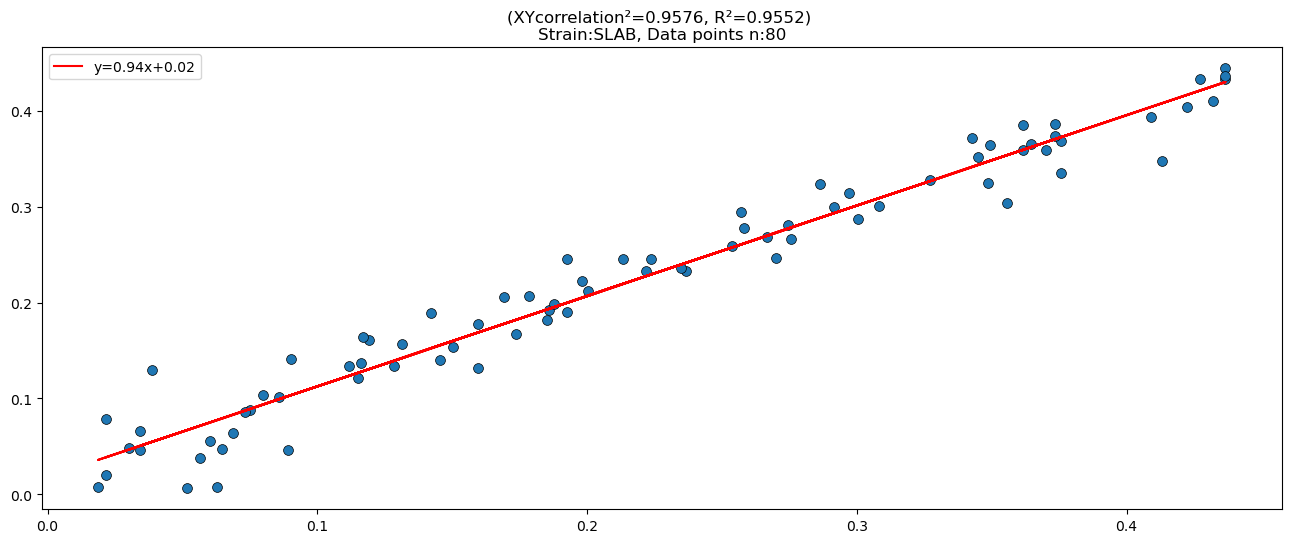

In [145]:
reservoir.X, reservoir.Y = Xtrain, Ytrain
# reservoir.b_ext, reservoir.b_int =  btrain, bint
X, Y = model_input(reservoir,verbose=False)
pred, stats = evaluate_model(reservoir.model, X, Y, reservoir, verbose=False)
yp =  pred[:,:end]

y = np.array(yp.flatten())
x = np.array(Ytrain).flatten()
m, b = np.polyfit(x, y, 1)
fig = plt.figure(figsize=(16,6))
ax1 = fig.subplots(1,1)
ax1.plot(x, m*x + b, color='red', label=f'y={m:.2f}x+{b:.2f}')
# find R2
correlation_matrix = np.corrcoef(x, y)
correlation_xy = correlation_matrix[0,1]
r_squared = correlation_xy**2

r_2 = r2_score(x, y)


subtitle= (f"Strain:{strain}, Data points n:{y.shape[0]}")
ax1.set_title(f"(XYcorrelation²={r_squared:.4f}, R²={r_2:.4f}) \n"
              f"{subtitle}"
              )
ax1.scatter(x, y,s=50,edgecolors='black', linewidths=0.5)
plt.legend()

In [118]:
# reservoirname = trainname+'_'+model.model_type + '_paper_params'
# reservoirfile = DIRECTORY+'Reservoir/'+reservoirname
# reservoir.save(reservoirfile)